Step 1: Import Required Libraries

In [72]:
%pip install -r requirements.txt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download("stopwords")

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\elifs\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Step 2: Load the Dataset

In [73]:
data = pd.read_csv('data/spam_ham_dataset.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [74]:
data.shape

(5171, 4)

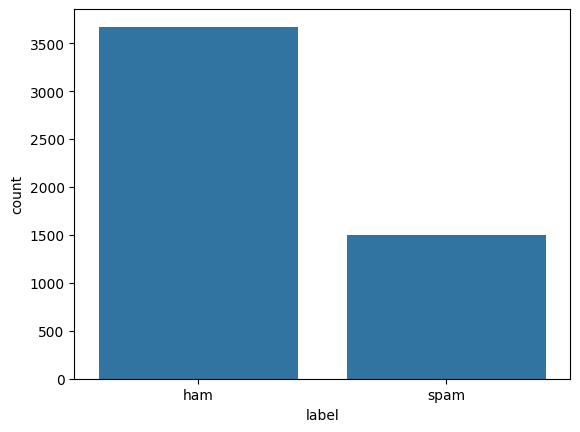

In [75]:
sns.countplot(x='label', data=data)
plt.show()

Step 3: Balancing Ham and Spam Email Dataset

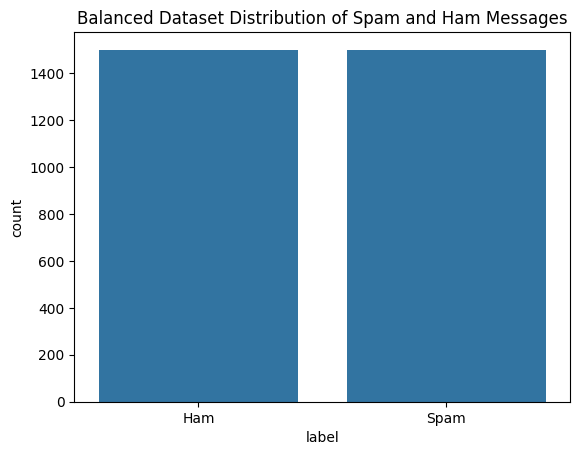

In [76]:
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

# Balancing the dataset by sampling the ham messages to match the number of spam messages
ham_msg_balanced = ham_msg.sample(spam_msg.shape[0], random_state=42) #42 is used for reproducibility

# Concatenating the balanced ham messages with the spam messages
balanced_data = pd.concat([ham_msg_balanced, spam_msg], axis=0).reset_index(drop=True)
balanced_data.shape

sns.countplot(x='label', data=balanced_data)
plt.title('Balanced Dataset Distribution of Spam and Ham Messages')
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
plt.show()

Step 4: Clean the Text - We do not neeed the text written Subject so we can clear that out

In [77]:
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [78]:
# Removing punctuations from the text
punctuations_list = string.punctuation
def remove_punctuations(text):
    temp = str.maketrans('', '', punctuations_list)
    return text.translate(temp)

balanced_data['text'] = balanced_data['text'].apply(lambda x: remove_punctuations(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


In [79]:
# Removing stopwords from the text
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    imp_words = []

    for word in str(text).split():
        word = word.lower()

        if word not in stop_words:
            imp_words.append(word)
    
    output = ' '.join(imp_words)
    return output

balanced_data['text'] = balanced_data['text'].apply(lambda x: remove_stopwords(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


Step 5: Visualising Word Cloud

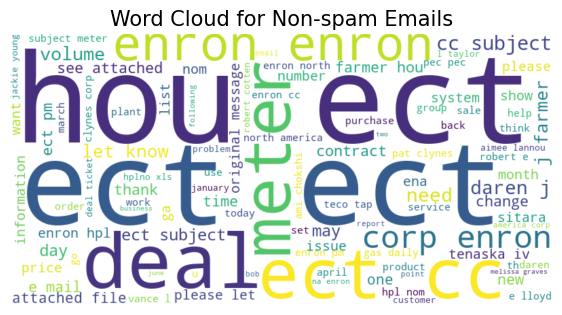

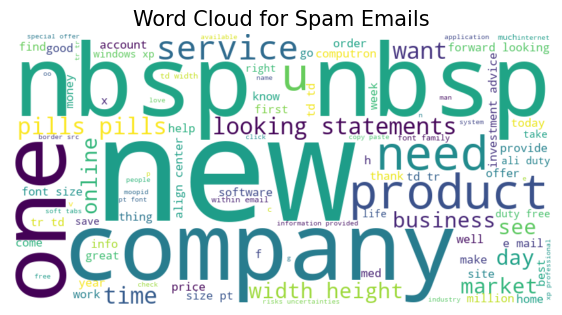

In [80]:
def plot_wordcloud(data, typ):
    email_corpus = ' '.join(data['text'])
    worldcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(worldcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {typ} Emails', fontsize=15)
    plt.show()

plot_wordcloud(balanced_data[balanced_data['label'] == 'ham'], typ = 'Non-spam')
plot_wordcloud(balanced_data[balanced_data['label'] == 'spam'], typ = 'Spam')

Step 6: Tokenisation and Padding

In [81]:
max_words = 10000
max_len = 100

train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['text'],
    balanced_data['label'],
    test_size=0.2,
    random_state=42,
    stratify=balanced_data['label']
)
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

train_sequences = pad_sequences(
    train_sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

test_sequences = pad_sequences(
    test_sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

Step 7: Define the Model

In [89]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(max_len,)),

    tf.keras.layers.Embedding(
        input_dim=max_words,
        output_dim=32
    ),

    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,713 (1.23 MB)

 Trainable params: 323,713 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

Step 8: Train the Model

In [90]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5897 - loss: 0.6720 - val_accuracy: 0.6083 - val_loss: 0.8629 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8695 - loss: 0.3961 - val_accuracy: 0.8767 - val_loss: 0.3691 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9191 - loss: 0.2758 - val_accuracy: 0.8867 - val_loss: 0.3446 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9341 - loss: 0.2379 - val_accuracy: 0.9000 - val_loss: 0.3266 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9491 - loss: 0.1916 - val_accuracy: 0.9117 - val_loss: 0.2910 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9558 - loss: 0.1655 - val_accuracy: 0.9250 - val_loss: 0.2459 - learning_rate: 0.0010
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9671 - loss: 0.1215 - val_acc

In [91]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9667 - loss: 0.1332 
Test Loss : 0.13319918513298035
Test Accuracy : 0.9666666388511658


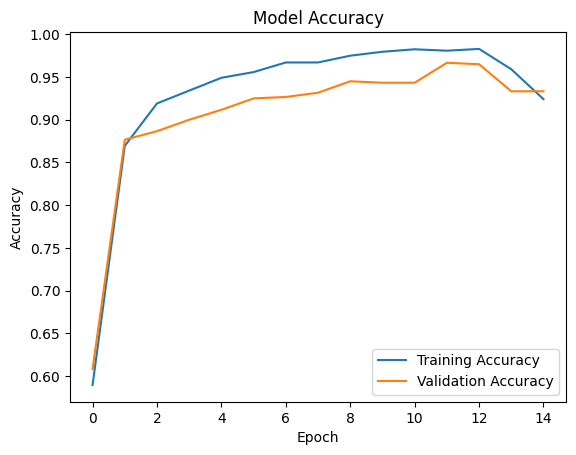

In [92]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [93]:
def clean_new_email(email_text):
    """
    Clean a new email using the same cleaning steps used for the training data.
    """

    # Convert email to string
    email_text = str(email_text)

    # Remove the word "Subject" like we did in the dataset
    email_text = email_text.replace("Subject", "")
    email_text = email_text.replace("subject", "")

    # Remove punctuation
    email_text = remove_punctuations(email_text)

    # Remove stopwords
    email_text = remove_stopwords(email_text)

    return email_text


def predict_email(email_text):
    """
    Predict whether a new email is spam or ham.
    """

    # Step 1: Clean the email
    cleaned_email = clean_new_email(email_text)

    # Step 2: Convert the email text into numbers using the SAME tokenizer
    email_sequence = tokenizer.texts_to_sequences([cleaned_email])

    # Step 3: Pad the sequence using the SAME max_len
    email_padded = pad_sequences(
        email_sequence,
        maxlen=max_len,
        padding='post',
        truncating='post'
    )

    # Step 4: Predict using the trained model
    spam_probability = model.predict(email_padded, verbose=0)[0][0]

    # Step 5: Convert probability into label
    if spam_probability >= 0.5:
        prediction = "Spam"
    else:
        prediction = "Ham"

    return {
        "Original Email": email_text,
        "Cleaned Email": cleaned_email,
        "Spam Probability": float(spam_probability),
        "Prediction": prediction
    }

In [ ]:
my_email = """
##Add your email text here to test the model. For example:
Subject: Congratulations! You have won a free iPhone.
Click this link now to claim your prize.
"""

result = predict_email(my_email)
result

{'Original Email': '\nSubject: Work From Home and Earn $5,000 Weekly\n\nHello,\n\nWe are offering a work-from-home opportunity with no experience required.\nEarn thousands of dollars every week by working only one hour per day.\n\nSign up immediately.\n',
 'Cleaned Email': 'work home earn 5000 weekly hello offering workfromhome opportunity experience required earn thousands dollars every week working one hour per day sign immediately',
 'Spam Probability': 0.9532007575035095,
 'Prediction': 'Spam'}